In [106]:
import numpy as np
import matplotlib.pyplot as plt

In [107]:
# Módulo para manejo de imágenes
import pandas as pd
from PIL import Image
from pathlib import Path

def process_image(img_path : str, rotate=False) -> np.ndarray:
    img = Image.open(img_path).convert("L")
    img_matrix = np.array(img)
    if rotate:
        return np.rot90(img_matrix, 2)
    return img_matrix

def read_images(folder : Path, csv : pd.DataFrame) -> np.ndarray:
    images = []
    tags = []
    for _, row in csv.iterrows():
        image_name = row["archivo"]
        tag = row["clase"]

        image_path = folder / image_name
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")  
        images.append(process_image(image_path))
        tags.append(tag)
    return np.array(images), np.array(tags) # Matrix con filas las realizaciones y Vector con las etiquetas asociadas

def flatten_images(images):
    return images.reshape(images.shape[0], -1)


In [108]:
# Entrenamiento y testeo de modelo
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

def train_classifier(lr_model : LogisticRegression, X : np.ndarray, y : np.ndarray) -> None:  
    lr_model.fit(X, y)
    return None
def test_classifier(lr_model : LogisticRegression, X : np.ndarray, y : np.ndarray) -> float: 
    y_pred = lr_model.predict(X)
    acc = accuracy_score(y, y_pred)
    return acc


In [109]:
# Principal Component Analysis via SVD
def fit_pca(X_train: np.ndarray):  
    mu = X_train.mean(axis=0)
    X_centered = X_train - mu
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return U, S, Vt, mu

def proyectar_componentes(X: np.ndarray, Vt: np.ndarray, mu: np.ndarray, K: int) -> np.ndarray:  
    Vk = Vt[:K, :].T                    # matriz de proyección (d, K), obtenida de train
    return (X - mu) @ Vk                # centrado con la media de train (parte del 'entrenamiento' de PCA)
                                        # para train esto es idéntico a U_k @ diag(S_k) 


### Por qué $(X - \mu)\,V_K = U_K S_K$ en train

**SVD de la matriz centrada de train.** Sea $X_c = X_{train} - \mu$ (de tamaño $n \times d$, con $\mu$ restada a cada fila). Su SVD reducida es

$$
X_c = U S V^T
$$

con $U$ de $n \times r$, $S = \mathrm{diag}(s_1, \dots, s_r)$ de $r \times r$ y $V$ de $d \times r$. Las columnas de $U$ y de $V$ son ortonormales:

$$
U^T U = I, \qquad V^T V = I
$$

**Proyección sobre todas las direcciones.** Multiplicando a la derecha por $V$:

$$
X_c V = U S V^T V = U S
$$

**Proyección sobre las primeras $K$ direcciones.** Sea $V_K$ la matriz con las primeras $K$ columnas de $V$ (de $d \times K$). Como las columnas de $V$ son ortonormales, $V^T V_K$ es la matriz de $r \times K$ que tiene la identidad $I_K$ arriba y ceros abajo. Entonces

$$
X_c V_K = U S \, (V^T V_K) = U_K S_K
$$

donde $U_K$ son las primeras $K$ columnas de $U$ y $S_K = \mathrm{diag}(s_1, \dots, s_K)$.

**Columna por columna.** La componente principal $j$ de las muestras de train es

$$
X_c \, v_j = s_j \, u_j, \qquad j = 1, \dots, K
$$

o sea, la coordenada de cada muestra sobre la dirección $v_j$ es el vector $u_j$ escalado por el valor singular $s_j$.

**Por qué no vale para test.** La igualdad usa que $X_c$ es exactamente la matriz que se descompuso. Para $X_{test}$ no existe una $U$ asociada, así que la única forma de proyectar es

$$
Z_{test} = (X_{test} - \mu)\, V_K
$$

con $\mu$ y $V_K$ obtenidos de train. Para train ambas expresiones coinciden:

$$
Z_{train} = (X_{train} - \mu)\, V_K = U_K S_K
$$

In [110]:
# Inciso C
N = 2000
def K_PCA(X_train, y_train, X_test, y_test, Vt, mu, Kmin=1, Kmax=100):  
    Ks = []
    accuracies = []  

    for K in range(Kmin, Kmax+1):
        lr_model = LogisticRegression(max_iter=N)
        Xk_train = proyectar_componentes(X_train, Vt, mu, K)  
        Xk_test = proyectar_componentes(X_test, Vt, mu, K)

        train_classifier(lr_model, Xk_train, y_train)
        accuracy = test_classifier(lr_model, Xk_test, y_test)
        Ks.append(K)
        accuracies.append(accuracy)

    return np.array(Ks), np.array(accuracies)

In [111]:
FIG_DIR = Path("../figures")  
FIG_DIR.mkdir(exist_ok=True)

training_folder = Path("../dataset_tp1/train")
df_train = pd.read_csv("../dataset_tp1/train_labels.csv")
X_train, y_train = read_images(training_folder, df_train)
X_train = flatten_images(X_train)

testing_folder = Path("../dataset_tp1/test")
df_test = pd.read_csv("../dataset_tp1/test_labels.csv")
X_test, y_test = read_images(testing_folder, df_test)
X_test = flatten_images(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (2428, 16384)  Test: (468, 16384)


In [112]:
# Inciso A: LR con las imágenes completas (sin PCA)
lr_model = LogisticRegression(max_iter=N)
train_classifier(lr_model, X_train, y_train)
accuracy_full = test_classifier(lr_model, X_test, y_test)
print("Accuracy reported: ", accuracy_full)  #! typo: Accuarcy -> Accuracy


Accuracy reported:  0.8183760683760684


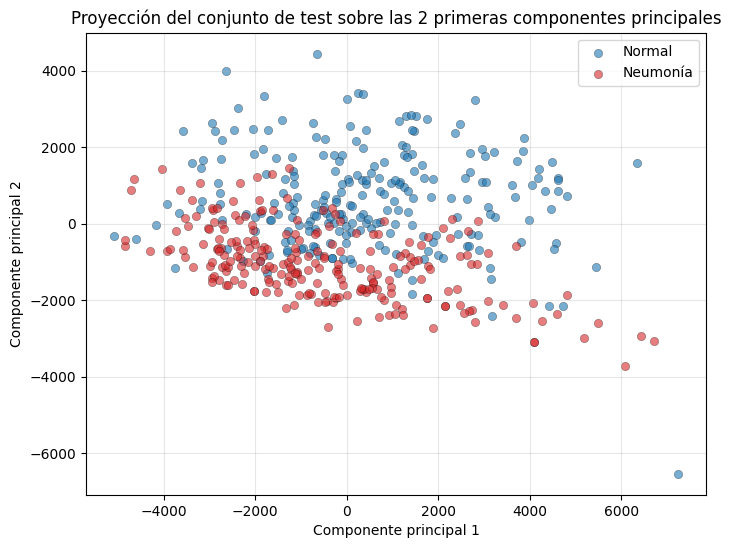

In [113]:
# Inciso B: proyección de test sobre las 2 primeras componentes principales
U, S, Vt, mu = fit_pca(X_train)  
X_test_proj = proyectar_componentes(X_test, Vt, mu, K=2)

# Scatter diferenciando clases por color
plt.figure(figsize=(8, 6))
colores = {0: "tab:blue", 1: "tab:red"}
etiquetas = {0: "Normal", 1: "Neumonía"}

for clase in [0, 1]:
    mask = y_test == clase
    plt.scatter(
        X_test_proj[mask, 0],
        X_test_proj[mask, 1],
        c=colores[clase],
        label=etiquetas[clase],
        alpha=0.6,
        edgecolors="k",
        linewidths=0.3,
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Proyección del conjunto de test sobre las 2 primeras componentes principales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "pca_scatter.png", dpi=150, bbox_inches="tight")  
plt.show()


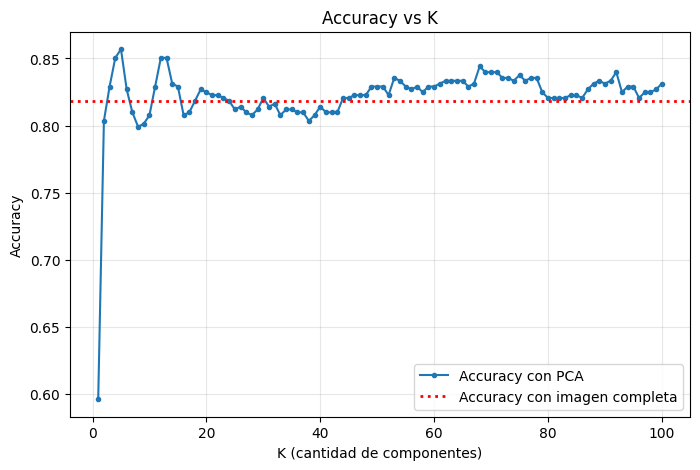

Accuracy sin PCA: 0.8184
Mejor accuracy con PCA: 0.8568 (K = 5)
Primer K que alcanza el accuracy sin PCA: K = 3


In [114]:
# Inciso C: accuracy vs K
Ks, accuracies = K_PCA(X_train, y_train, X_test, y_test, Vt, mu)  # reutiliza la PCA ajustada en el inciso B

plt.figure(figsize=(8, 5))
# Puntos (K, accuracy)
plt.plot(Ks, accuracies, marker="o", markersize=3, linestyle="-", label="Accuracy con PCA")

# Línea punteada con el accuracy de la imagen completa (inciso a)
plt.axhline(y=accuracy_full, color="red", linestyle=":", linewidth=2, label="Accuracy con imagen completa")  

plt.xlabel("K (cantidad de componentes)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "accuracy_vs_k.png", dpi=150, bbox_inches="tight")  
plt.show()

print(f"Accuracy sin PCA: {accuracy_full:.4f}")
print(f"Mejor accuracy con PCA: {accuracies.max():.4f} (K = {Ks[accuracies.argmax()]})")
print(f"Primer K que alcanza el accuracy sin PCA: K = {Ks[np.argmax(accuracies >= accuracy_full)]}")


<!-- ! celda nueva: la consigna del inciso (c) pide "analice los resultados obtenidos" y el notebook no tenía ningún análisis -->
### Análisis del inciso (c)

- **Baseline (inciso a):** la regresión logística sobre las imágenes completas (16384 píxeles) obtiene un accuracy de 0.818 sobre test.
- **K = 1:** el accuracy cae a ~0.60, apenas por encima del azar (las clases están balanceadas). Una sola componente, que captura mayormente el brillo/contraste global de la radiografía, no separa las clases.
- **K = 2:** ya se llega a 0.80, consistente con el scatter del inciso (b), donde las dos clases se ven separadas principalmente a lo largo de la componente 2 aunque con bastante solapamiento.
- **K = 3 a 5:** con solo 3 componentes se iguala el baseline (0.829) y con K = 5 se obtiene el máximo (0.857). Es decir, con 5 números por imagen en lugar de 16384 el clasificador funciona igual o mejor: la información discriminante está concentrada en las primeras componentes y el resto de las direcciones son en gran parte redundantes o ruido.
- **K grande:** a partir de K ≈ 20 el accuracy oscila alrededor del baseline (entre ~0.80 y ~0.84) sin una tendencia clara de mejora. Las componentes de baja varianza aportan poca información útil y agregan parámetros al modelo, por lo que no hay ganancia en conservarlas. El baseline no es un techo: es una LR con 16384 parámetros ajustada con solo 2428 muestras, así que reducir la dimensión también regulariza.
- **Oscilaciones:** el test tiene 468 imágenes, por lo que una diferencia de 0.01 en accuracy corresponde a ~5 imágenes. Buena parte de las subidas y bajadas entre K consecutivos es variabilidad de muestreo y no debe sobreinterpretarse.


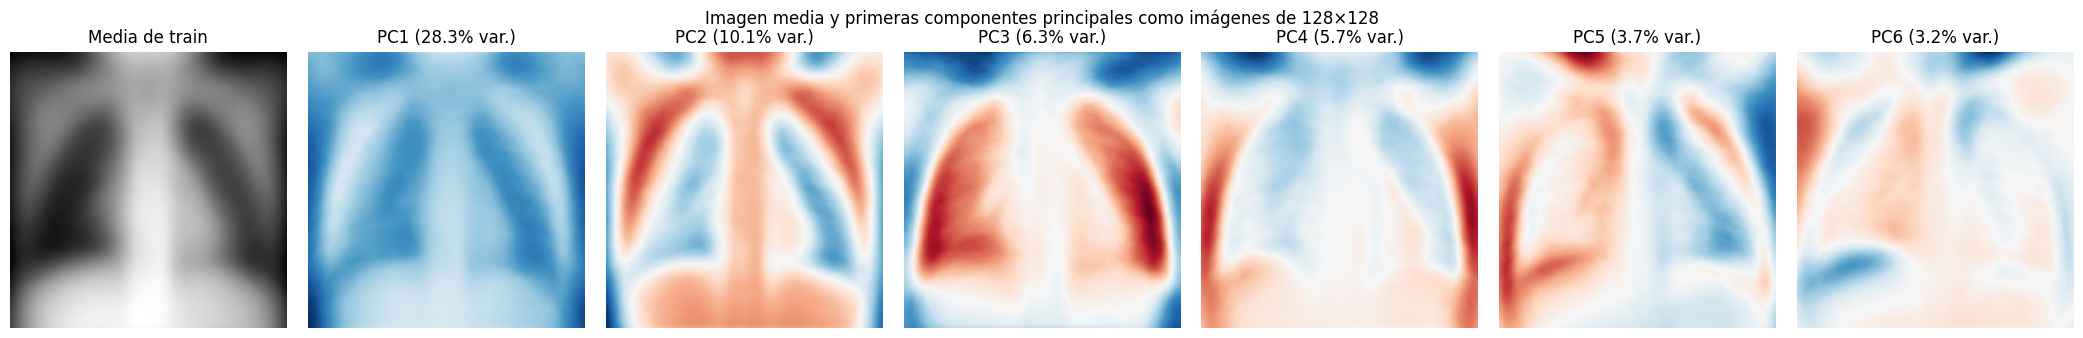

In [115]:
# Extra: imagen media y primeras componentes principales vistas como imágenes
# Cada fila de Vt es una dirección principal con un valor por píxel (16384 = 128*128),
# así que se puede reacomodar como imagen y ver "a qué zonas del tórax mira" cada componente.
lado = int(np.sqrt(X_train.shape[1]))   # 128
n_comp = 6                              # cantidad de componentes a mostrar

fig, axes = plt.subplots(1, n_comp + 1, figsize=(3 * (n_comp + 1), 3.4))

# Imagen media de train: es lo que se resta a cada imagen antes de proyectar
axes[0].imshow(mu.reshape(lado, lado), cmap="gray")
axes[0].set_title("Media de train")

# Componentes principales: colormap divergente centrado en 0 para distinguir
# píxeles con peso positivo (rojo) y negativo (azul). El signo global de cada
# componente es arbitrario (la SVD puede devolver v o -v); importa el contraste entre zonas.
for j in range(n_comp):
    pc = Vt[j].reshape(lado, lado)
    lim = np.abs(pc).max()
    axes[j + 1].imshow(pc, cmap="RdBu_r", vmin=-lim, vmax=lim)
    var_j = S[j] ** 2 / np.sum(S ** 2)   # fracción de la varianza total que captura la componente
    axes[j + 1].set_title(f"PC{j + 1} ({100 * var_j:.1f}% var.)")

for ax in axes:
    ax.axis("off")

plt.suptitle("Imagen media y primeras componentes principales como imágenes de 128×128")
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_componentes_imagenes.png", dpi=150, bbox_inches="tight")
plt.show()



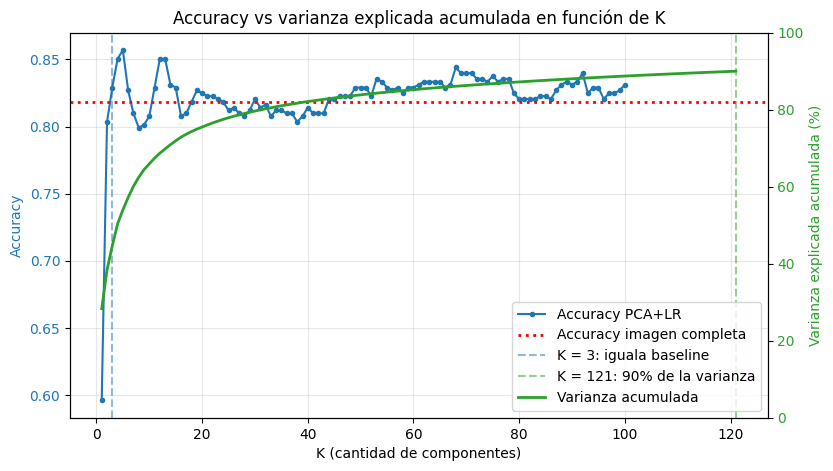

K =   1: varianza acumulada =  28.3%   accuracy = 0.596
K =   2: varianza acumulada =  38.4%   accuracy = 0.803
K =   3: varianza acumulada =  44.7%   accuracy = 0.829
K =   5: varianza acumulada =  54.0%   accuracy = 0.857
K =  10: varianza acumulada =  66.0%   accuracy = 0.808
K =  20: varianza acumulada =  75.5%   accuracy = 0.825
K =  50: varianza acumulada =  83.9%   accuracy = 0.829
K = 100: varianza acumulada =  88.7%   accuracy = 0.831
Para retener el 90% de la varianza hacen falta 121 componentes; el accuracy iguala al baseline con K = 3


In [116]:
# Extra: varianza explicada acumulada vs accuracy, en función de K
# Cada valor singular al cuadrado es la varianza que captura esa componente.
# Sumando las primeras K y dividiendo por el total se obtiene qué fracción de la
# variabilidad de train se conserva al proyectar a K dimensiones.
var_explicada = S ** 2 / np.sum(S ** 2)
var_acumulada = np.cumsum(var_explicada)

# K necesario para retener el 90% de la varianza (criterio clásico para elegir K en PCA)
K_90 = np.argmax(var_acumulada >= 0.90) + 1
# Primer K con el que PCA+LR iguala al accuracy de la imagen completa (reutiliza Ks y accuracies del inciso c)
K_baseline = Ks[np.argmax(accuracies >= accuracy_full)]

fig, ax_acc = plt.subplots(figsize=(9, 5))

# Eje izquierdo: accuracy (misma curva del inciso c)
ax_acc.plot(Ks, accuracies, marker="o", markersize=3, color="tab:blue", label="Accuracy PCA+LR")
ax_acc.axhline(accuracy_full, color="red", linestyle=":", linewidth=2, label="Accuracy imagen completa")
ax_acc.set_xlabel("K (cantidad de componentes)")
ax_acc.set_ylabel("Accuracy", color="tab:blue")
ax_acc.tick_params(axis="y", labelcolor="tab:blue")

# Eje derecho: varianza acumulada. Se extiende más allá del Kmax del inciso (c) para que llegue al 90%
K_var = np.arange(1, max(Ks.max(), K_90) + 1)
ax_var = ax_acc.twinx()
ax_var.plot(K_var, 100 * var_acumulada[K_var - 1], color="tab:green", linewidth=2, label="Varianza acumulada")
ax_var.set_ylabel("Varianza explicada acumulada (%)", color="tab:green")
ax_var.tick_params(axis="y", labelcolor="tab:green")
ax_var.set_ylim(0, 100)

# Líneas verticales: dónde satura el accuracy y dónde se llega al 90% de varianza
ax_acc.axvline(K_baseline, color="tab:blue", linestyle="--", alpha=0.5, label=f"K = {K_baseline}: iguala baseline")
ax_acc.axvline(K_90, color="tab:green", linestyle="--", alpha=0.5, label=f"K = {K_90}: 90% de la varianza")

# Leyenda combinada de los dos ejes
h1, l1 = ax_acc.get_legend_handles_labels()
h2, l2 = ax_var.get_legend_handles_labels()
ax_acc.legend(h1 + h2, l1 + l2, loc="lower right")
ax_acc.grid(True, alpha=0.3)
plt.title("Accuracy vs varianza explicada acumulada en función de K")
plt.savefig(FIG_DIR / "accuracy_vs_varianza.png", dpi=150, bbox_inches="tight")
plt.show()

for K in [1, 2, 3, 5, 10, 20, 50, 100]:
    print(f"K = {K:3d}: varianza acumulada = {100 * var_acumulada[K - 1]:5.1f}%   accuracy = {accuracies[K - 1]:.3f}")
print(f"Para retener el 90% de la varianza hacen falta {K_90} componentes; el accuracy iguala al baseline con K = {K_baseline}")


### Análisis de las figuras extra

**Qué hacen las dos celdas anteriores.**

- *Componentes como imágenes:* cada fila de $V^T$ es una dirección principal con un peso por píxel, así que se puede reacomodar en una grilla de 128×128 y verla como imagen. La celda muestra la imagen media de train (lo que se resta antes de proyectar) y las primeras seis componentes con un colormap divergente: rojo es peso positivo, azul es peso negativo, blanco es peso nulo. La coordenada de una imagen sobre la componente $j$ es el producto interno entre la imagen centrada y ese mapa, o sea un promedio ponderado de sus píxeles con esos pesos. El signo global de cada componente es arbitrario (la SVD puede devolver $v$ o $-v$); lo interpretable es el contraste entre zonas.
- *Varianza acumulada vs. accuracy:* la varianza que captura la componente $j$ es $s_j^2$, y la fracción acumulada hasta $K$ es $\sum_{j \le K} s_j^2 / \sum_j s_j^2$. La celda superpone esa curva a la de accuracy del inciso (c) y marca el $K$ donde el accuracy iguala al baseline y el $K$ donde la varianza llega al 90%.

**Qué muestran.**

- La **PC1** (28% de la varianza) tiene el mismo signo en toda la imagen: su coordenada es esencialmente el brillo total de la radiografía (en el anexo se ve que el 100% de sus pesos comparten signo y que la correlación con el brillo medio de la imagen es −0.98). Eso depende de la exposición del equipo y del tamaño del paciente, no de la enfermedad, y explica que con $K = 1$ el accuracy sea ~0.60.
- La **PC2** (10%) es azul en los campos pulmonares y roja en la periferia: mide cuánto brillan los pulmones respecto del resto del tórax. Un pulmón sano es oscuro porque está lleno de aire; la neumonía produce opacidades que lo aclaran. Por eso el scatter del inciso (b) separa las clases sobre el eje vertical y el accuracy salta de 0.60 a 0.80 al pasar de $K = 1$ a $K = 2$. Es la única componente que discrimina por sí sola: una LR con esa única coordenada alcanza 0.78 de accuracy, contra 0.60 con la PC1 (ver anexo).
- Las **PC3 a PC6** muestran patrones de variación de las imágenes (brillo pulmonar global, encuadre, asimetría izquierda-derecha) que no están asociados a la clase. Solas no superan el 0.60 de accuracy y su cociente de Fisher es 20 veces menor que el de la PC2 (ver anexo); la mejora hasta $K = 5$ viene de combinarlas con las dos primeras en la LR.
- El accuracy iguala al baseline con $K = 3$ (45% de la varianza) y alcanza el máximo con $K = 5$ (54%). Para retener el 90% de la varianza harían falta 121 componentes, y en todo ese tramo el accuracy no mejora.

**Por qué son valiosos estos gráficos.** Las figuras de los incisos (b) y (c) muestran *que* PCA funciona; estas dos muestran *por qué*. La primera convierte los ejes abstractos del scatter en mapas del tórax y permite verificar visualmente la interpretación de cada componente. La segunda contrasta el criterio clásico para elegir $K$ (retener cierta fracción de la varianza) con la métrica que realmente importa (accuracy), y muestra que en este problema el criterio clásico sobreestima $K$ en más de un orden de magnitud.

**Qué nos dicen sobre PCA para clasificación de imágenes.**

- PCA es un método **no supervisado**: ordena las direcciones por varianza sin mirar la etiqueta. Varianza y capacidad discriminante son cosas distintas. Acá la dirección de mayor varianza (brillo global) no sirve para clasificar, y la que discrimina es la segunda.
- Que funcione tan bien con $K = 5$ es una propiedad de este dataset, no una garantía del método: la opacidad pulmonar resulta ser la segunda fuente de variación más grande de las imágenes. Si la señal de la clase fuera un detalle fino de baja varianza, quedaría en componentes altas y PCA la descartaría al truncar.
- Aun así, la reducción tiene dos beneficios claros: baja el costo (5 números por imagen en lugar de 16384) y **regulariza**. La LR sobre imágenes completas ajusta 16384 parámetros con 2428 muestras y no supera a la LR con 5 componentes.
- Como consecuencia práctica, para elegir $K$ en un problema de clasificación conviene mirar el desempeño del clasificador en función de $K$ (como en el inciso c) y no solo la varianza retenida.

**Anexo.** La celda siguiente calcula, para cada una de las primeras seis componentes, la fracción de varianza que captura, el porcentaje de píxeles cuyo peso comparte signo con el peso dominante, el cociente de Fisher entre clases sobre train y el accuracy en test de una LR entrenada con esa única coordenada. Son los números que respaldan la interpretación de arriba.


### El cociente de Fisher

**Qué es.** Para una variable escalar $z$ (acá, la coordenada de cada imagen sobre una componente principal) y dos clases con medias $\mu_0, \mu_1$ y varianzas $\sigma_0^2, \sigma_1^2$, se define

$$
F = \frac{(\mu_0 - \mu_1)^2}{\sigma_0^2 + \sigma_1^2}
$$

El numerador mide qué tan lejos están los centros de las dos clases; el denominador, qué tan anchas son las nubes de cada clase. Es adimensional: no cambia si se reescala $z$, lo que permite comparar componentes que tienen escalas muy distintas (la PC1 tiene coordenadas mucho más grandes que la PC6 porque captura más varianza).

**De dónde sale.** Es el criterio que Fisher propuso en 1936 para el *análisis discriminante lineal*: dada una nube de datos con dos clases, buscar la dirección $w$ sobre la cual la proyección $z = w^T x$ maximiza $F$. Acá no se usa para buscar una dirección nueva, sino para evaluar las direcciones que ya eligió PCA.

**Por qué funciona.** Que cada clase forme una sola nube en el scatter del inciso (b) indica que las distribuciones de cada coordenada son unimodales, y eso es lo único que se necesita para que media y varianza resuman bien a cada clase. Bajo ese supuesto, la superposición entre las dos clases depende de la distancia entre las medias medida en unidades de desviación estándar, que es lo que resume $F$. Como referencia, si además fueran gaussianas: con $F \approx 0$ las distribuciones se pisan por completo y un umbral sobre $z$ acierta casi al azar; con $F \approx 1$ la separación entre medias es del orden de $\sqrt{2}$ desviaciones estándar y un umbral en el punto medio acierta en torno al 76%. Cuanto mayor es $F$, mejor separa la coordenada. No tiene cota superior: dos clases sin superposición dan un $F$ arbitrariamente grande.

**Por qué es valioso en este trabajo.**

- PCA elige direcciones por **varianza**, sin mirar las etiquetas. El cociente de Fisher mide justo lo que PCA no mira: la **separación entre clases**. Calcularlo por componente permite ver de forma directa qué parte de la varianza retenida es útil para clasificar y qué parte no.
- No depende de ningún clasificador: se calcula solo con medias y varianzas de train. En el anexo también se reporta el accuracy en test de una LR entrenada con esa única componente, que es otra forma de medir lo mismo, pero ese número depende además de cómo ajustó la LR y de qué imágenes cayeron en test. Como las dos medidas coinciden en que la PC2 es la única componente que separa, la conclusión no depende de cuál de las dos se mire.
- Le pone un número a lo que el scatter del inciso (b) muestra a ojo: las nubes están corridas sobre el eje vertical (PC2, $F = 1.48$) y casi centradas sobre el horizontal (PC1, $F = 0.23$). Para las PC3 a PC6, $F$ está entre 0.03 y 0.07, o sea, no separan.
- Resume en una comparación la limitación de PCA para clasificación: la dirección de máxima varianza y la de máxima separación no tienen por qué coincidir, y en este dataset no coinciden.


In [117]:
# Anexo: poder discriminante de cada componente por separado
# Para cada una de las primeras componentes se calcula:
#  - % de píxeles con el mismo signo que el peso dominante (100% => la componente mide brillo total)
#  - cociente de Fisher entre clases: (media_normal - media_neumonía)^2 / (var_normal + var_neumonía),
#    calculado sobre train; cuanto mayor, mejor separa las clases esa coordenada sola
#  - accuracy en test de una LR entrenada con esa única coordenada
n_comp = 6
Z_train = proyectar_componentes(X_train, Vt, mu, n_comp)
Z_test = proyectar_componentes(X_test, Vt, mu, n_comp)

print(f"{'PC':<4}{'% var.':>8}{'% mismo signo':>15}{'Fisher':>9}{'acc. 1 comp.':>14}")
for j in range(n_comp):
    var_j = S[j] ** 2 / np.sum(S ** 2)
    v = Vt[j]
    mismo_signo = np.mean(np.sign(v) == np.sign(v[np.abs(v).argmax()]))
    z0, z1 = Z_train[y_train == 0, j], Z_train[y_train == 1, j]
    fisher = (z0.mean() - z1.mean()) ** 2 / (z0.var() + z1.var())
    lr_1d = LogisticRegression(max_iter=N)
    train_classifier(lr_1d, Z_train[:, [j]], y_train)
    acc_1d = test_classifier(lr_1d, Z_test[:, [j]], y_test)
    print(f"PC{j + 1:<2}{100 * var_j:8.1f}{100 * mismo_signo:15.1f}{fisher:9.3f}{acc_1d:14.3f}")

# Correlación entre la coordenada PC1 y el brillo medio de cada imagen de train
brillo_medio = X_train.mean(axis=1)
print(f"\nCorrelación entre PC1 y brillo medio de la imagen: {np.corrcoef(Z_train[:, 0], brillo_medio)[0, 1]:.3f}")


PC    % var.  % mismo signo   Fisher  acc. 1 comp.
PC1     28.3          100.0    0.232         0.596
PC2     10.1           35.7    1.477         0.784
PC3      6.3           57.0    0.067         0.583
PC4      5.7           53.9    0.074         0.592
PC5      3.7           50.0    0.031         0.491
PC6      3.2           44.7    0.063         0.436

Correlación entre PC1 y brillo medio de la imagen: -0.982
